# Домашнее задание 2. Работа с изображениями

В этом задании предлагается решить простейшую задачу рапознавания лиц. Вам нужно будет научить модель для пары картинок определять, разные ли люди на них изображены.

Работать будем с датасетом фотографий известных людей. Скачать его можно [тут](https://disk.360.yandex.ru/d/oAmJgPESjP33hg). В нём представлены 150 человек, для каждого по 6-9 фотографий. Всего около 1000 изображений.

__Задание__. Вам потребуется выполнить два задания:

1) Реализовать модель бинарной классификации и добиться приемлемого качества.

2) Реализовать триплетную функцию потерь и улучшить качество предсказаний с ее помощью.

Напишите краткий отчёт о проделанных экспериментах. Что сработало и что не сработало? Почему вы решили, сделать так, а не иначе? Обязательно указывайте ссылки на чужой код, если вы его используете. Обязательно ссылайтесь на статьи / блогпосты / вопросы на stackoverflow / видосы от ютуберов-машинлернеров / курсы / подсказки от Дяди Васи и прочие дополнительные материалы, если вы их используете.

__Во всех заданиях будем придерживаться следующих правил__:
1. Использовать внешние данные для обучения строго запрещено. Также запрещено обучаться на валидационной выборке.
2. Все задания должны быть выполнены без использования предобученных моделей и готовых реализаций. Тем не менее:
    - В заданиях, где требуется достичь некоторого качества модели, разрешается использовать предобученные модели. Но __оценка за задние будет снижена__ (для каждого задания будет отдельно указано, на сколько).
    - В некоторых заданиях может сильно помочь библотека [pytorch-metric-learning](https://kevinmusgrave.github.io/pytorch-metric-learning/). Вы можете использовать готовые реализации из неё, но __максимальный балл за задание также будет снижен__.

__Советы и указания__:
 - Наверняка вам потребуется много гуглить о том, как заставить это всё работать. Это нормально, все гуглят. Но не забывайте, что нужно быть готовым за скатанный код отвечать :)
 - Рекомендуем использовать шаблоны ниже. Однако делать это мы не заставляем. Если вам так неудобно, то можете писать код в удобном стиле. Однако учтите, что чрезмерное изменение нижеперечисленных шаблонов увеличит количество вопросов к вашему коду :)
 - Валидируйте. Трекайте ошибки как можно раньше, чтобы не тратить время впустую.
 - Чтобы быстро отладить код, пробуйте обучаться на маленькой части датасета (скажем, 5-10 картинок просто чтобы убедиться что код запускается). Когда вы поняли, что смогли всё отдебажить, переходите обучению по всему датасету
 - На каждый запуск делайте ровно одно изменение в модели/аугментации/оптимайзере, чтобы понять, что и как влияет на результат.
 - Фиксируйте random seed.
 - Правильно нормализуйте данные при создании, пример [тык, но тут и в целом гайд от и до](https://www.pluralsight.com/guides/image-classification-with-pytorch)
 - Начинайте с простых моделей и постепенно переходите к сложным. Обучение лёгких моделей экономит много времени. Можно написать свою модель руками, а можно импортировать не предобученную сетку известной архитектуры из модуля `torchvision.models`. Один из способов как можно сделать: [документация (полезная)](https://pytorch.org/vision/stable/models.html)
 - Используйте все возможные методы оптимизации и эксперемнтируйте с ними.
 - Ставьте расписание на learning rate. Уменьшайте его, когда лосс на валидации перестаёт убывать.
 - Model Checkpointing. Сохраняйте свой прогресс (модели), чтобы когда что-то пойдет не так вы сможете начать с этого места или просто воспроизвести свои результаты модели, которые обучали.
    * Пример как можно с wandb тут: [Сохраняем лучшие модели в wandb](https://docs.wandb.ai/guides/integrations/lightning)
    * По простому можно так: [Сохраняем модели в pytorch дока](https://pytorch.org/tutorials/beginner/saving_loading_models.html)
 - Советуем использовать GPU. Если у вас его нет, используйте google colab. Если вам неудобно его использовать на постоянной основе, напишите и отладьте весь код локально на CPU, а затем запустите уже написанный ноутбук в колабе.

Good luck & have fun! :)

In [1]:
import os
import tqdm
import numpy as np
import torch
import pandas
import random
import torchvision
import sklearn.metrics
import torch.utils.data
import matplotlib.pyplot as plt
import torchvision.transforms.v2

In [2]:
# Обязательно вызывайте эту функцию перед каждый запуском обучения!
# Если проверяющий не сможет воспроизвести результат, оценка за задание будет снижена.
def set_random_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [3]:
!unzip "/content/data.zip"

Archive:  /content/data.zip
   creating: data/
   creating: data/testing/
   creating: data/testing/Albert_Costa/
  inflating: data/testing/Albert_Costa/Albert_Costa_0001.jpg  
  inflating: data/testing/Albert_Costa/Albert_Costa_0002.jpg  
  inflating: data/testing/Albert_Costa/Albert_Costa_0003.jpg  
  inflating: data/testing/Albert_Costa/Albert_Costa_0004.jpg  
  inflating: data/testing/Albert_Costa/Albert_Costa_0005.jpg  
  inflating: data/testing/Albert_Costa/Albert_Costa_0006.jpg  
   creating: data/testing/Cameron_Diaz/
  inflating: data/testing/Cameron_Diaz/Cameron_Diaz_0001.jpg  
  inflating: data/testing/Cameron_Diaz/Cameron_Diaz_0002.jpg  
  inflating: data/testing/Cameron_Diaz/Cameron_Diaz_0003.jpg  
  inflating: data/testing/Cameron_Diaz/Cameron_Diaz_0004.jpg  
  inflating: data/testing/Cameron_Diaz/Cameron_Diaz_0005.jpg  
  inflating: data/testing/Cameron_Diaz/Cameron_Diaz_0006.jpg  
   creating: data/testing/Mohamed_ElBaradei/
  inflating: data/testing/Mohamed_ElBaradei/M

### [1.5 балла] Часть 1. Подготовка данных.

##### [0.5 балла] Задание 1.1. Считать датасет.

Сначала нужно считать датасет с фотографиями и посмотреть на его устройство.

In [4]:
from torchvision import transforms
transform = transforms.Compose(
    [
        transforms.ToTensor()
    ]
)

train_ds = torchvision.datasets.ImageFolder("data/training", transform = transform)
test_ds = torchvision.datasets.ImageFolder("data/testing", transform = transform)

Давайте посмотрим на примеры фотографий. Нарисуйте несколько.

In [5]:
images = []
names =[]
for i in range(10, 101, 10):
  image, name_idx = train_ds[i]
  images.append(image)
  names.append(train_ds.classes[name_idx])

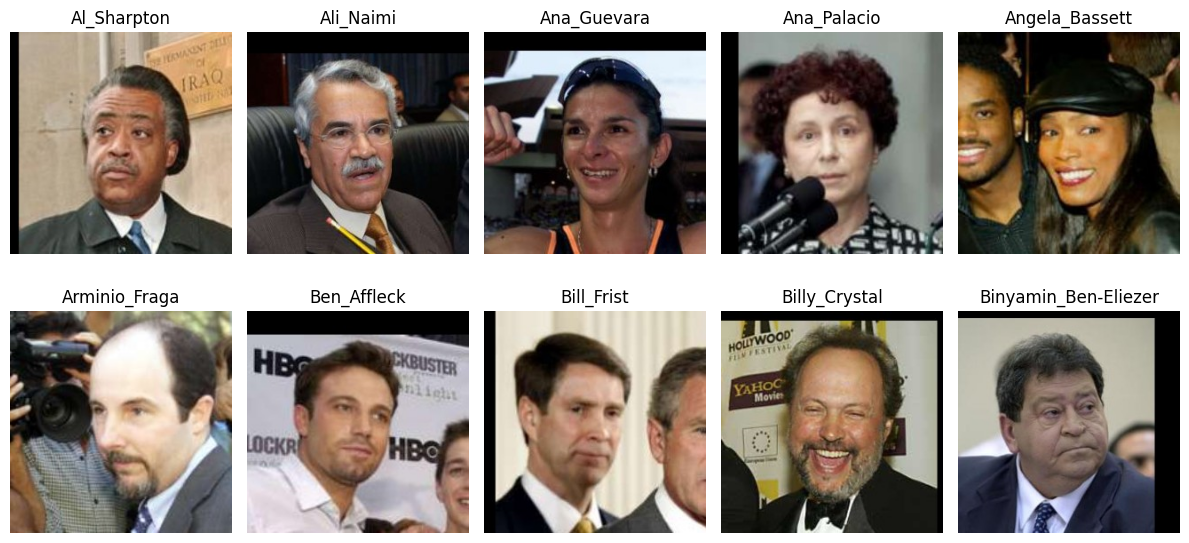

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.flatten()

for i in range(10):
  npimg = images[i].numpy()
  axes[i].imshow(np.transpose(npimg, (1, 2, 0)))
  axes[i].set_title(names[i])
  axes[i].axis('off')

plt.tight_layout()
plt.show()

Наконец, следует вывести распределение фотографий по людям и убедиться, что для каждого человека действительно предствалено 6-9 фотографий.

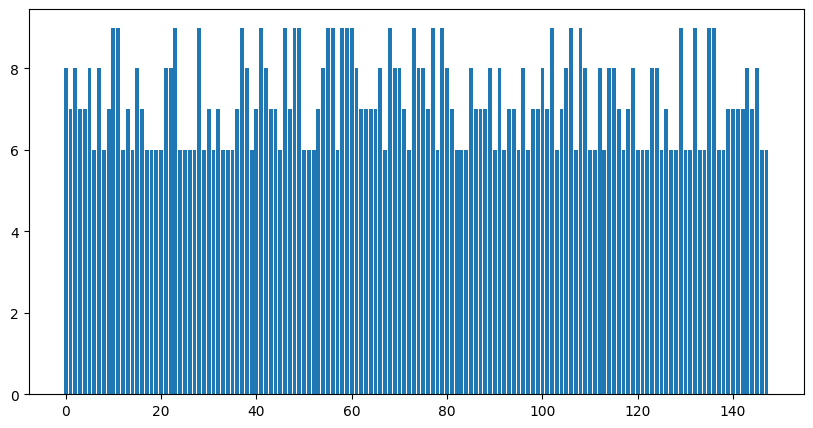

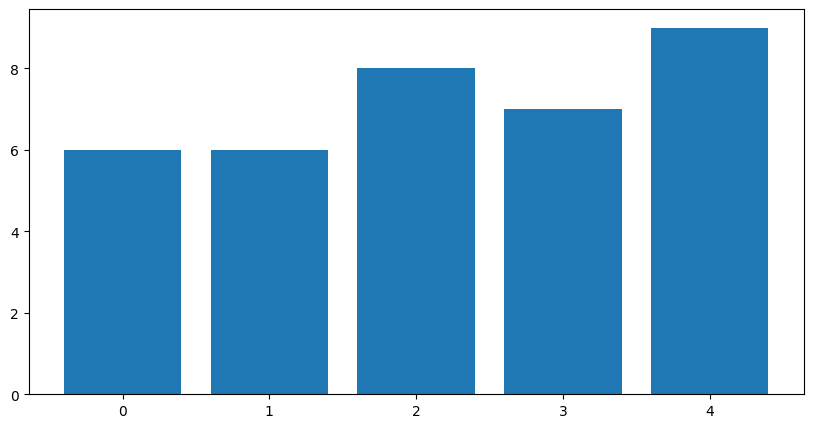

In [7]:
def show_class_distribtion(targets):
    classes, count = np.unique(targets, return_counts = True)
    plt.figure(figsize=(10, 5))
    plt.bar(classes, count)
    plt.show()

show_class_distribtion(train_ds.targets)
show_class_distribtion(test_ds.targets)

##### [0 баллов] Задание 1.2. Датасет пар.

Как было сказано ранее, мы будем обучать модели предсказывать, разные ли люди изображены на фотографиях. Для этого нам надо научиться формировать пары фотографий и целевую переменную из двух классов: 0 и 1. \
Класс 0 означает, что это фотографии одного человека. \
Класс 1 означает фотографии разных людей. \
 \
К счастью, весь датасет уже написан.

In [8]:
class PairDataset(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
        self.targets = [ self._get_target(i) for i in tqdm.trange(len(self)) ]

    def _idx1(self, idx):
        return idx % len(self.dataset)

    def _idx2(self, idx):
        return idx // len(self.dataset)

    def _get_target(self, idx):
        return int(self.dataset.targets[self._idx1(idx)] != self.dataset.targets[self._idx2(idx)])

    def __len__(self):
        return len(self.dataset) ** 2

    def __getitem__(self, idx):
        idx = int(idx)
        image1, label1 = self.dataset[self._idx1(idx)]
        image2, label2 = self.dataset[self._idx2(idx)]
        return image1, image2, int(label1 != label2)

train_pairs = PairDataset(train_ds)
test_pairs = PairDataset(test_ds)

100%|██████████| 1296/1296 [00:00<00:00, 829136.36it/s]


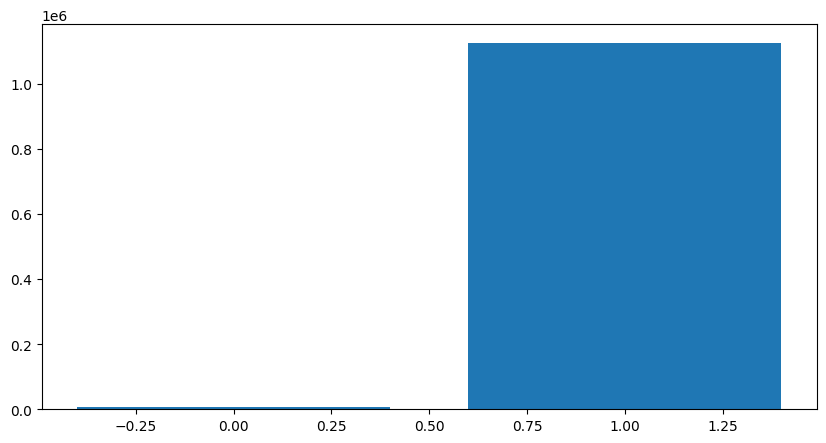

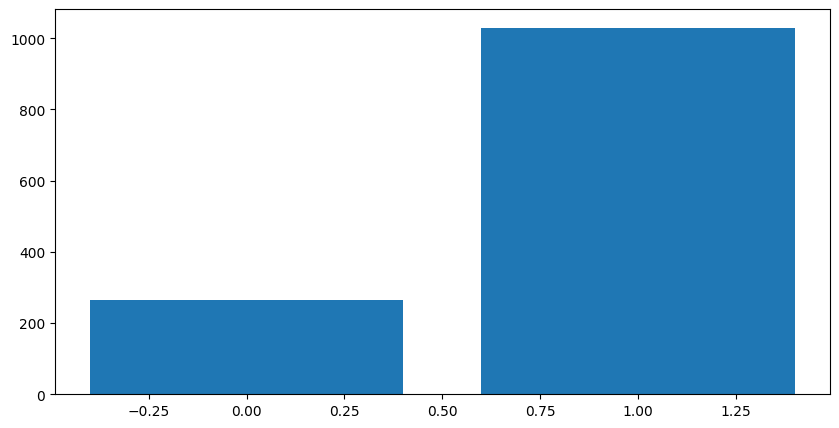

In [9]:
show_class_distribtion(train_pairs.targets)
show_class_distribtion(test_pairs.targets)

Легко видеть, что пар фотографий разных людей гораздо больше, чем пар фотографий одного человека. Это вполне ожидаемо, но, если не предпринять мер, ведет к двум проблемам:
1. Метрика качества предсказаний должна учитывать дисбаланс классов. В частности, accuracy нам не подойдёт. А использовать будем известный из курса машинного обучения AUC-ROC.
2. Нужно "подтюнить" даталоадер тренировочных данных, чтобы в каждый батч попадало примерно одинаковое количество фотографий каждого класса. Иначе победить деградацию модели к "всегда 1" будет очень сложно.

##### [1 балл] Задание 1.3. Стратифицированный даталоадер.

Для начала решим вторую проблему. Нужно сделать такой даталоадер, чтобы в каждом батче количество элементов класса "0" совпадало с количеством элементов класса "1".

Как известно, стандартный класс `DataLoader` в torch имеет много параметров. В частности, параметр `sampler` позволяет гибко управлять выдачей. Изучите [документацию](https://docs.pytorch.org/docs/stable/data.html#data-loading-order-and-sampler) и реализуйте свой семплер, который решит проблему.

В `pytorch_metric_learning` уже есть готовая реализация того, что нам нужно. Вы можете её найти и использовать. Но в таком случае __максимальный балл за это задание - 0.4__.

In [10]:
from torch.utils.data import Sampler
from typing import List, Iterator
import random
from math import ceil

class MySampler(Sampler[List[int]]):
    def __init__(self, targets: List[int], batch_size: int) -> None:
        self.targets = targets
        self.batch_size = batch_size

        pos_idx = [idx for idx, cl in enumerate(self.targets) if cl == 0]
        neg_idx = [idx for idx, cl in enumerate(self.targets) if cl == 1]

        random.shuffle(pos_idx)
        random.shuffle(neg_idx)

        neg_idx = neg_idx[:len(pos_idx)]

        self.res = [item for x in zip(pos_idx, neg_idx) for item in x]

    def __len__(self) -> Iterator[List[int]]:
        return ceil(len(self.res)/ self.batch_size)

    def __iter__(self) -> Iterator[int]:
        for i in range(0, len(self.res), self.batch_size):
            batch = self.res[i:i + self.batch_size]
            yield batch

In [11]:
train_pairs_sampler =  MySampler(train_pairs.targets, 32)

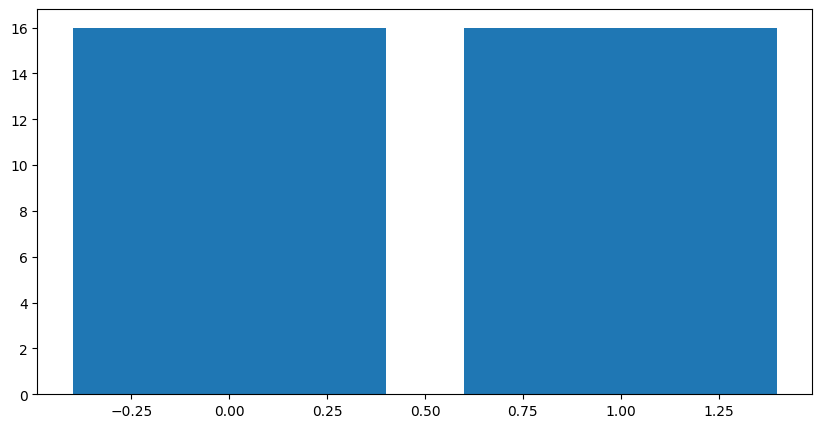

In [12]:
train_pairs_loader = torch.utils.data.DataLoader(train_pairs, batch_sampler = train_pairs_sampler)
test_pairs_loader = torch.utils.data.DataLoader(test_pairs, batch_size = 64, shuffle = False)

# Убедимся, что теперь выдача равномерная.
show_class_distribtion(next(iter(train_pairs_loader))[2])

### [3.5 балла] Часть 2. Классификация.

Начнём с простого: попробуем решить проблему как обычную задачу бинарной классификации. Реализуйте и обучите обычную свёрточную сеть, которая принимает два набора фотографий и предсказывает вероятность, что это фотографии разных людей.

##### [1 балл] Задание 2.1. Модель классификации.

Сначала нужно реализовать модель. В `forward` необходимо принять два батча фотографий. `i`-e число в выводе `forward` должно быть предсказанием для пары из `i`-й фотографии `image1` и `i`-й фотографии `image2`. Подумайте, как это сделать. Возможно, стоит как-нибудь склеить `image1` и `image2`? Или склеить эмбеддинги? А может быть нужен какой-то трешхолд?

Вы вольны использовать любую архитектуру сети. Ассерт в конце ячейки поможет вам убедиться, что модель теоретически делает то, что нужно.

Посмотрим на размер изображений:

In [13]:
batch = next(iter(train_pairs_loader))
batch[0].shape

torch.Size([32, 3, 250, 250])

**Вариант 1: нейронная сеть с одним сверточным слоем и тремя полносвязными слоями**

In [14]:
class ClassificationNet1(torch.nn.Module):
    def __init__(self):
      super(ClassificationNet1, self).__init__()
      self.vgg = torch.nn.Sequential(
          torch.nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding='same'),
          torch.nn.ReLU(),
          torch.nn.MaxPool2d(kernel_size=2, stride=2)
      )

      self.fc = torch.nn.Sequential(
          torch.nn.Flatten(),
          torch.nn.Linear(16 * 125 * 125, 128),
          torch.nn.ReLU()
      )

      self.prob = torch.nn.Sequential(
          torch.nn.Linear(128 * 2, 64),
          torch.nn.ReLU(),
          torch.nn.Linear(64, 1),
          torch.nn.Sigmoid()
      )

    def forward(self, image1, image2):
      image1_features = self.vgg(image1)
      image1_features = self.fc(image1_features)

      image2_features = self.vgg(image2)
      image2_features = self.fc(image2_features)

      concat_features = torch.cat((image1_features, image2_features), dim=1)
      return self.prob(concat_features).squeeze(1)


# Вы можете использовать этот ассерт в качестве теста, что ваша модель делает то, что нужно.
assert ClassificationNet1()(*next(iter(train_pairs_loader))[:2]).shape == (32,)

##### [2 балла] Задание 2.2. Обучение.

Теперь обучите свою модель и добейтесь приемлемого качества. Балл за это задание вычисляется по формуле:

$$ clamp(0, 2.5 \cdot \dfrac{AucRoc - 0.6}{0.2}, 2.5) $$

То есть, для получения полного балла за это задание необходимо добиться AUC-ROC `0.8`

__При использовани предобученных моделей, балл за это задание умножается на 0.5__ (то есть, не более 1)

**Функции для обучения модели:**

In [15]:
def training_epoch(model, optimizer, criterion, train_loader, tqdm_desc):
    train_loss, train_accuracy = 0.0, 0.0
    model.train()
    for images1, images2, labels in tqdm.tqdm(train_loader, desc=tqdm_desc):
      images1 = images1.to(device)
      images2 = images2.to(device)
      labels = labels.float().to(device)

      optimizer.zero_grad()

      logits = model(images1, images2)
      loss = criterion(logits, labels)
      loss.backward()
      optimizer.step()

      train_loss += loss.item() * labels.shape[0]
      train_accuracy += ((logits > 0.5).float() == labels).sum().item()

    train_loss /= len(train_loader.dataset)
    train_accuracy /= len(train_loader.dataset)
    return train_loss, train_accuracy

@torch.no_grad()
def validation_epoch(model, criterion, val_loader, tqdm_desc):
  val_loss, val_accuracy = 0.0, 0.0
  model.eval()
  for images1, images2, labels in tqdm.tqdm(val_loader, desc=tqdm_desc):
      images1 = images1.to(device)
      images2 = images2.to(device)
      labels = labels.float().to(device)

      logits = model(images1, images2)
      loss = criterion(logits, labels)

      val_loss += loss.item() * labels.shape[0]
      val_accuracy += ((logits > 0.5).float() == labels).sum().item()

  val_loss /= len(val_loader.dataset)
  val_accuracy /= len(val_loader.dataset)
  return val_loss, val_accuracy

def train(model, optimizer, criterion, train_loader, val_loader, num_epochs, scheduler=None):
  set_random_seed(42)
  train_losses, train_accuracies = [], []
  val_losses, val_accuracies = [], []

  for epoch in range(1, num_epochs + 1):
      train_loss, train_accuracy = training_epoch(
          model, optimizer, criterion, train_loader,
          tqdm_desc=f'Training {epoch}/{num_epochs}',
      )
      val_loss, val_accuracy = validation_epoch(
          model, criterion, val_loader,
          tqdm_desc=f'Validating {epoch}/{num_epochs}'
      )

      train_losses.append(train_loss)
      train_accuracies.append(train_accuracy)
      val_losses.append(val_loss)
      val_accuracies.append(val_accuracy)

      if scheduler is not None:
          scheduler.step()
      print(f"Epoch: {epoch}, loss: {val_loss:.4f}, accuracy: {val_accuracy:.4f}")

In [16]:
def get_score(auc_roc):
    return max(0, min(2.5 * (auc_roc - 0.6) / 0.2, 2.5))

def get_auc_roc(your_model):
    preds = []
    targets = []
    your_model.eval()
    for images1, images2, labels in tqdm.tqdm(test_pairs_loader):
        with torch.no_grad():
            output = your_model(images1.to(device), images2.to(device))
        preds.extend(output.detach().cpu().tolist())
        targets.extend(labels.detach().cpu().tolist())
    preds = np.array(preds)
    targets = np.array(targets)
    return sklearn.metrics.roc_auc_score(targets, preds)

**Обучаем первую нейросеть с одним сверточным слоем:**

In [17]:
set_random_seed(42)
model1 = ClassificationNet1().to(device)
optimizer = torch.optim.Adam(model1.parameters(), lr=0.001, betas=(0.9, 0.999))
criterion = torch.nn.BCELoss()
set_random_seed(42)
train(model1, optimizer, criterion, train_pairs_loader, test_pairs_loader, num_epochs=5)
res = get_auc_roc(model1)
print()
print(res, get_score(res))

Validating 1/5: 100%|██████████| 21/21 [00:04<00:00,  4.21it/s]


Epoch: 1, loss: 0.6755, accuracy: 0.5880


Validating 2/5: 100%|██████████| 21/21 [00:05<00:00,  4.19it/s]


Epoch: 2, loss: 0.6524, accuracy: 0.5656


Validating 3/5: 100%|██████████| 21/21 [00:05<00:00,  3.87it/s]


...

Epoch: 4, loss: 0.4837, accuracy: 0.7438


Validating 5/5: 100%|██████████| 21/21 [00:05<00:00,  3.88it/s]


Epoch: 5, loss: 0.4639, accuracy: 0.8040


100%|██████████| 21/21 [00:05<00:00,  4.16it/s]


0.8554274034601066 2.5


**Вариант 2: нейросеть с 2 сверточными слоями и батч-нормализацией, полносвязных слоев - 3**

In [18]:
class ClassificationNet2(torch.nn.Module):
    def __init__(self):
      super(ClassificationNet2, self).__init__()
      self.vgg = torch.nn.Sequential(
          torch.nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding='same'),
          torch.nn.BatchNorm2d(16),
          torch.nn.ReLU(),
          torch.nn.MaxPool2d(kernel_size=2, stride=2),

          torch.nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding='same'),
          torch.nn.BatchNorm2d(32),
          torch.nn.ReLU(),
          torch.nn.MaxPool2d(kernel_size=2, stride=2),
      )

      self.fc = torch.nn.Sequential(
          torch.nn.Flatten(),
          torch.nn.Linear(32 * 62 * 62, 128),
          torch.nn.ReLU()
      )

      self.prob = torch.nn.Sequential(
          torch.nn.Linear(128 * 2, 64),
          torch.nn.ReLU(),
          torch.nn.Linear(64, 1),
          torch.nn.Sigmoid()
      )

    def forward(self, image1, image2):
      image1_features = self.vgg(image1)
      image1_features = self.fc(image1_features)

      image2_features = self.vgg(image2)
      image2_features = self.fc(image2_features)

      concat_features = torch.cat((image1_features, image2_features), dim=1)
      return self.prob(concat_features).squeeze(1)


# Вы можете использовать этот ассерт в качестве теста, что ваша модель делает то, что нужно.
assert ClassificationNet2()(*next(iter(train_pairs_loader))[:2]).shape == (32,)

**Обучаем вторую нейросеть с двумя сверточными слоями:**

In [19]:
set_random_seed(42)
model2 = ClassificationNet2().to(device)
optimizer = torch.optim.Adam(model2.parameters(), lr=0.001, betas=(0.9, 0.999))
criterion = torch.nn.BCELoss()
set_random_seed(42)
train(model2, optimizer, criterion, train_pairs_loader, test_pairs_loader, num_epochs=5)
res = get_auc_roc(model2)
print()
print(res, get_score(res))

Validating 1/5: 100%|██████████| 21/21 [00:05<00:00,  3.88it/s]


Epoch: 1, loss: 0.7098, accuracy: 0.4799


Validating 2/5: 100%|██████████| 21/21 [00:05<00:00,  3.88it/s]


Epoch: 2, loss: 0.6637, accuracy: 0.6142


Validating 3/5: 100%|██████████| 21/21 [00:05<00:00,  3.65it/s]


...

Epoch: 4, loss: 0.5204, accuracy: 0.7068


Validating 5/5: 100%|██████████| 21/21 [00:05<00:00,  3.88it/s]


Epoch: 5, loss: 0.5281, accuracy: 0.7284


100%|██████████| 21/21 [00:05<00:00,  3.62it/s]


0.8204357982334478 2.5


**Считаем roc-auc:**

In [20]:
res1 = get_auc_roc(model1)
print(f'Первая модель: auc-roc = {res1},  оценка за задание = {get_score(res1)}')
res2 = get_auc_roc(model2)
print(f'\nВторая модель: auc-roc = {res2},  оценка за задание = {get_score(res2)}')

100%|██████████| 21/21 [00:05<00:00,  4.08it/s]


Первая модель: auc-roc = 0.8554274034601066,  оценка за задание = 2.5


100%|██████████| 21/21 [00:05<00:00,  3.73it/s]


Вторая модель: auc-roc = 0.8204357982334478,  оценка за задание = 2.5


##### [0.5 балла] Задание 2.3. Анализ и отчет.

Опишите свои эксперименты. Проанализируйте результаты. Почему результаты получились не очень хорошими? Может быть, решать задачу через бинарную классификацию - не лучшая идея? Приведите не менее 3 аргументов, почему это так.

**Вывод:**

Было обучено 2 разных архитектуры нейросети. Наилучшей оказалась самая простая модель.

Первая модель работает лучше, хотя архитектура достаточно простая. Модель состоит из одного сверточного слоя и 3 полносвязных слоев, без нормализации и дропаутов. Сеть быстро обучается за счет своей простоты.

Можно предположить, что эту модель можно улучшить, так как в ней всего один сверточный слой, который не позволяет находить сложные паттерны на изображениях. Поэтому я построила вторую сеть, в которую был добавлен второй сверточный слой и батч-нормализация.

Для второй модели auc-roc меньше, то есть модель стала работать хуже. Возможно, она так плохо сработала, потому что усложнение архитектуры привело к переобучению. Модель могла начать запоминать фон изображения, слишком мелкие детали и на основе них делать выводы. Я пробовала еще как-то скорректировать модель но результаты получались около 0.8, лучше 0.85 не получилось(

В целом, модели показали не очень хорошие результаты, поэтому, можно сказать, что бинарная классификация для задачи распознавания людей - это плохой вариант, потому что:

1. Модель учится определять один и тот же человек на картинке или нет, но не учитывает того, что один и тот же человек в разные периоды жизни, на разных фотографиях выглядит по-разному. Она не ищет схожие черты, которые потом бы можно было сравнить, например на первом изображении зеленые глаза, прямые длинные волосы, прямой нос, широкий лоб и человек стоит на ярком фоне, а на втором все то же самое, но волосы кудрявые и темно. Если бы мы ввели меру сходства людей на изображениях, то пришли бы к выводу, что это один и тот же человек, но бинарная классификация рассматривает изображение глобально - похожи в целом или нет, что может привести к неточной работе.

2.  Очень много вычислений нужно сделать, чтобы для нового изображения определить, есть ли изображение такого человека в базе. То есть нужно прогнать это изображение со всеми, что уже имеются. Это неэффективно.

3. Кроме того, в бинарной классификации для распознавания лиц есть проблема с балансом классов(одинаковых картинок в разы меньше, чем разных), и хоть мы и решили это с помощью сэмплера, но это все равно искажает данные. Если мы решаем проблему дисбаланса путем урезания бОльшего класса, то мы теряем большое кол-во данных, а если мы наоборот дублируем элементы меньшего класса, то модель слишком часто видит одни и те же изображения и может на них сильно переобучиться.

### [5 баллов] Часть 3. Распознавание лиц.

Теперь попробуем использовать более хитрые методы, которые лучше подходят для решаемой задачи. В частности, триплетную функцию потерь. Далее наша модель будет не предсказывать вероятность для двух картинок, а формировать эмбеддинги для одной картинки таким образом, чтобы эмбеддинги фотографий одного человека были близки, а разных людей - далеки.

##### [2 балла] Задание 3.1. Триплетная функция потерь.

Напомним теорию. Пусть $A$ - произвольное изображение; $P$ - изображение того же человека (позитивный пример); $N$ - изображение любого другого человека (негативный пример); $f$ - наша нейронная сеть; $\alpha$ - гиперпараметр, отвечающий за желаемый “отступ” – расстояние между латентными представлениями изображений разных людей. Тогда функционал ошибки определяется следующим образом:

$$ L(A, P, N) = max(||f(A) - f(P)|| - ||f(A) - f(N)|| + \alpha, 0) $$

В этом задании вам необходимо реализовать этот функционал. Для удобства в дальнейшем, предлагается сразу реализовать batch-версию. Таким образом, на входе должно быть 2 параметра:
- Набор эмбеддингов размера (batch_size, embedding_size)
- Набор классов (номера людей, чьи это фотографии) размера (batch_size)

Ваша функция должна найти все тройки $(A, P, N)$ и вычислить лосс для них.

В `pytorch_metric_learning` уже есть готовая реализация. Вы можете её найти и использовать. Но в таком случае __максимальный балл за это задание - 0.5__.

In [29]:
def criterion(embeddings, targets, margin = 0.25):
  pos_images = targets[:, None] == targets
  pos_images.fill_diagonal_(False)

  neg_images = targets[:, None] != targets
  losses = []
  total_batch_loss = 0.0
  count_triplets = 0
  for i in range(len(embeddings)):
    if len(embeddings[pos_images[i]]) == 0 or len(embeddings[neg_images[i]]) == 0:
      continue
    pos_diff = torch.norm(embeddings[i].unsqueeze(0) - embeddings[pos_images[i]], p=2, dim=1)
    neg_diff = torch.norm(embeddings[i].unsqueeze(0) - embeddings[neg_images[i]], p=2, dim=1)

    for diff1 in pos_diff:
      for diff2 in neg_diff:
        loss = diff1 - diff2 + margin
        res = torch.clamp(loss, min=0)
        losses.append(res)
        count_triplets += 1
  if count_triplets != 0:
    average_batch_loss = torch.stack(losses).mean()
  else:
    average_batch_loss = torch.tensor(0.0, requires_grad=True, device=embeddings.device)
  return average_batch_loss

In [30]:
# Вы можете использовать этот ассерт в качестве теста
embeddings = torch.tensor([
    [ 1., 2, 3 ],
    [ 1, 3, 4 ],
    [ 4, 5, 6 ]
])
labels = torch.tensor([ 1., 2, 1 ])
assert (criterion(embeddings, labels) - 2.6775) < 1e-4

##### [3 балла] Задание 3.2. Обучение.

Теперь обучите модель и добейтесь приемлемого качества. Балл за это задание вычисляется по формуле:

$$ clamp(0, 3 \cdot \dfrac{AucRoc - 0.8}{0.15}, 3) $$

То есть, для получения полного балла за это задание необходимо добиться AUC-ROC `0.95`

При необходимости, вы можете улучшить функцию потерь. Например, учитывать не все тройки, а только "сложные", как это умеет делать реализация в `pytorch_metric_learning`. Также подумайте над даталоадером. Возможно, имеет смысл брать в батч одинаковое количество фотографий каждого человека по аналгии с заданием 1.3? Тем не менее имейте в виду, что для получения полного балла за задание, вы должны реализовать все модификации самостоятельно, а не использовать готовые.

__При использовани предобученных моделей, балл за это задание умножается на 0.5__ (то есть, не более 1.5) \
__При использовани pytorch_metric_learning, балл за это задание уменьшается на 0.5 за каждое использование__

In [31]:
def training_epoch(model, optimizer, train_loader, margin, tqdm_desc):
    train_loss, train_accuracy = 0.0, 0.0
    model.train()
    for images, labels in tqdm.tqdm(train_loader, desc=tqdm_desc):
      images = images.to(device)
      labels = labels.to(device)

      optimizer.zero_grad()

      embeddings = model(images)
      loss = criterion(embeddings, labels, margin)
      loss.backward()
      optimizer.step()

      train_loss += loss.item() * labels.shape[0]

    train_loss /= len(train_loader.dataset)
    return train_loss

@torch.no_grad()
def validation_epoch(model, val_loader, margin, tqdm_desc):
  val_loss, val_accuracy = 0.0, 0.0
  model.eval()
  for images, labels in tqdm.tqdm(val_loader, desc=tqdm_desc):
      images = images.to(device)
      labels = labels.to(device)

      embeddings = model(images)
      loss = criterion(embeddings, labels, margin)

      val_loss += loss.item() * labels.shape[0]

  val_loss /= len(val_loader.dataset)
  return val_loss

def train(model, optimizer, train_loader, val_loader, num_epochs, margin = 0.25, scheduler=None):
  set_random_seed(42)
  train_losses = []
  val_losses = []

  for epoch in range(1, num_epochs + 1):
      train_loss = training_epoch(
          model, optimizer, train_loader, margin,
          tqdm_desc=f'Training {epoch}/{num_epochs}',
      )
      val_loss = validation_epoch(
          model, val_loader, margin,
          tqdm_desc=f'Validating {epoch}/{num_epochs}'
      )

      train_losses.append(train_loss)
      val_losses.append(val_loss)

      if scheduler is not None:
          scheduler.step()
      print(f"Epoch: {epoch}, loss: {val_loss:.4f}")

In [32]:
def get_score(auc_roc):
    return max(0, min(3 * (auc_roc - 0.8) / 0.15, 3))

def get_auc_roc(your_model):
    preds = []
    targets = []
    your_model.eval()
    for images1, images2, labels in tqdm.tqdm(test_pairs_loader):
        with torch.no_grad():
            emb1 = your_model(images1.to(device))
            emb2 = your_model(images2.to(device))
            dist = ((emb1 - emb2) ** 2).sum(dim = 1)
        preds.extend(dist.detach().cpu().tolist())
        targets.extend(labels.detach().cpu().tolist())
    preds = np.array(preds)
    targets = np.array(targets)
    return sklearn.metrics.roc_auc_score(targets, preds)

In [33]:
train_loader = torch.utils.data.DataLoader(train_ds, batch_size = 32, shuffle = True)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size = 64, shuffle = False)

In [34]:
class ClassificationNet(torch.nn.Module):
    def __init__(self):
      super(ClassificationNet, self).__init__()
      self.vgg = torch.nn.Sequential(
          torch.nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding='valid'),
          torch.nn.ReLU(),
          torch.nn.MaxPool2d(kernel_size=2, stride=2),
          torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding='valid'),
          torch.nn.ReLU(),
          torch.nn.MaxPool2d(kernel_size=2, stride=2)
      )

      self.fc = torch.nn.Sequential(
          torch.nn.Flatten(),
          torch.nn.Linear(16 * 61 * 61, 128),
          torch.nn.ReLU(),
          torch.nn.Linear(128, 64),
          torch.nn.ReLU(),
      )

    def forward(self, image):
      image_features = self.vgg(image)
      image_features = self.fc(image_features)

      return image_features

In [35]:
set_random_seed(42)
model = ClassificationNet().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
set_random_seed(42)
train(model, optimizer, train_loader, test_loader, num_epochs=10, margin = 0.1)
res = get_auc_roc(model)
print()
print(res, get_score(res))

Validating 1/10: 100%|██████████| 1/1 [00:00<00:00,  3.44it/s]


Epoch: 1, loss: 0.0699


Validating 2/10: 100%|██████████| 1/1 [00:00<00:00,  3.47it/s]


Epoch: 2, loss: 0.0586


Validating 3/10: 100%|██████████| 1/1 [00:00<00:00,  2.13it/s]


...

Epoch: 9, loss: 0.0479


Validating 10/10: 100%|██████████| 1/1 [00:00<00:00,  3.37it/s]


Epoch: 10, loss: 0.0397


100%|██████████| 21/21 [00:05<00:00,  3.87it/s]


0.860792758595518 1.2158551719103583


Я выжала из себя все, что могла (｡•́︿•̀｡)
Сеть с одним сллоем, которая была написана во 2 задании, работает не очень хорошо, поэтому я добавила еще слой, стало получше, модель стала распознавать больше паттернов.

##### [0.1 балла] Бонус: распознай себя

В качестве бонуса, загрузите свою фотографию (можно не одну), пропустите ее через модель и определите, на кого из известных людей, по мнению модели, вы больше всего похоже.

In [28]:
### YOUR CODE HERE ###